第07回で実装した ```quantize``` 関数を使って，グレースケール画像（$[0, 255]$ の範囲）の画素値を
ビット深度 $B = 1, 2, 4, 8$ で量子化した画像をそれぞれ表示しなさい．
ビット深度を下げると画像の見え方がどのように変化するか考察しなさい．

In [1]:
def quantize(x, n_bits, x_min=-1.0, x_max=1.0):
    """振幅を [x_min, x_max] の範囲で n_bits 段階に量子化"""
    L = 2 ** n_bits
    step = (x_max - x_min) / (L - 1)
    return np.round((x - x_min) / step) * step + x_min

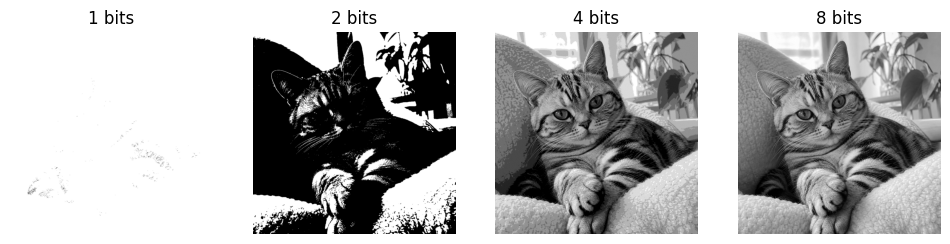

In [3]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/home/syamashita/initial-training-2026/syamashita-tu/chapter12/cat.png").convert("L")
img_array = np.array(img) / 255.0
B = [1,2,4,8]
fig, axes = plt.subplots(1, len(B), figsize=(12, 4))
for i in range(4):
    quantized_img_array = quantize(img_array, n_bits=B[i])
    axes[i].imshow(quantized_img_array, cmap="gray")
    axes[i].set_title(f"{B[i]} bits")
    axes[i].axis("off")
plt.show()